In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("smart_grid_dataset.csv")

print("Dataset preview:")
print(df.head())

print("\nColumns:")
print(df.columns.tolist())

Dataset preview:
      Voltage    Current  Resistance  From Node  To Node  Conductance
0  216.184375  16.312557       13.25          1        5     0.075472
1  235.567787  14.363618       16.40          4        5     0.060976
2  229.058407  13.660371       16.77          4        3     0.059630
3  220.313612  14.768926       14.92          1        4     0.067024
4  233.550635  15.478231       15.09          4        2     0.066269

Columns:
['Voltage', 'Current', 'Resistance', 'From Node', 'To Node', 'Conductance']


In [2]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nRows where From Node = To Node:")
print(df[df["From Node"] == df["To Node"]])

print("\nRows with invalid node values (not 1 to 5):")
print(df[(df["From Node"] < 1) | (df["From Node"] > 5) | (df["To Node"] < 1) | (df["To Node"] > 5)])

Missing values per column:
Voltage        0
Current        0
Resistance     0
From Node      0
To Node        0
Conductance    0
dtype: int64

Rows where From Node = To Node:
Empty DataFrame
Columns: [Voltage, Current, Resistance, From Node, To Node, Conductance]
Index: []

Rows with invalid node values (not 1 to 5):
Empty DataFrame
Columns: [Voltage, Current, Resistance, From Node, To Node, Conductance]
Index: []


In [3]:
n_nodes = 5
A = np.zeros((n_nodes, n_nodes))

for _, row in df.iterrows():
    i = int(row["From Node"]) - 1
    j = int(row["To Node"]) - 1
    G = float(row["Conductance"])

    A[i, i] += G
    A[j, j] += G
    A[i, j] -= G
    A[j, i] -= G

print("Full conductance matrix A:")
print(A)

Full conductance matrix A:
[[27.696412 -6.265802 -8.258203 -6.474805 -6.697602]
 [-6.265802 25.32835  -5.971355 -6.739529 -6.351664]
 [-8.258203 -5.971355 27.433308 -6.786467 -6.417283]
 [-6.474805 -6.739529 -6.786467 24.950228 -4.949427]
 [-6.697602 -6.351664 -6.417283 -4.949427 24.415976]]


Reduced matrix A (Node 5 is reference):
[[27.696412 -6.265802 -8.258203 -6.474805]
 [-6.265802 25.32835  -5.971355 -6.739529]
 [-8.258203 -5.971355 27.433308 -6.786467]
 [-6.474805 -6.739529 -6.786467 24.950228]]
Vector b:
[10.  5.  0.  3.]
Exact node voltages:
Node 1: 0.876098 V
Node 2: 0.745873 V
Node 3: 0.602449 V
Node 4: 0.712935 V
Node 5: 0.000000 V (reference)


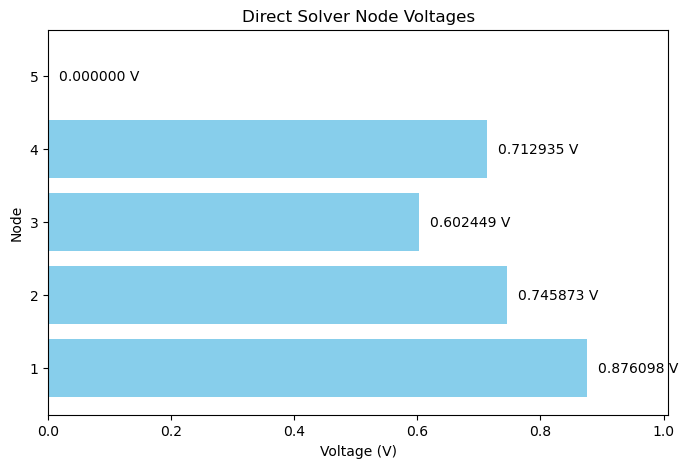

In [4]:
A_reduced = A[:-1, :-1]

print("Reduced matrix A (Node 5 is reference):")
print(A_reduced)

b = np.array([10, 5, 0, 3], dtype=float)

print("Vector b:")
print(b)


x_exact = np.linalg.solve(A_reduced, b)

print("Exact node voltages:")
for idx, val in enumerate(x_exact, start=1):
    print(f"Node {idx}: {val:.6f} V")

print("Node 5: 0.000000 V (reference)")

import matplotlib.pyplot as plt
import numpy as np

nodes = [1, 2, 3, 4, 5]
direct_voltages = list(x_exact) + [0]  

y_pos = np.arange(len(nodes))  

plt.figure(figsize=(8,5))
plt.barh(y_pos, direct_voltages, color='skyblue')

plt.yticks(y_pos, nodes)

offset = max(direct_voltages) * 0.02

for i, v in enumerate(direct_voltages):
    plt.text(v + offset, y_pos[i], f"{v:.6f} V", va='center')

plt.xlabel("Voltage (V)")
plt.ylabel("Node")
plt.title("Direct Solver Node Voltages")

plt.xlim(0, max(direct_voltages) * 1.15)

plt.show()

In [5]:
def jacobi_method(A, b, tol=1e-6, max_iter=100):
    n = len(b)
    x = np.zeros(n)
    x_new = np.zeros(n)
    iterations = 0

    for k in range(max_iter):
        for i in range(n):
            s = sum(A[i, j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i, i]

        iterations += 1

        if np.linalg.norm(x_new - x, ord=np.inf) < tol:
            return x_new, iterations

        x = x_new.copy()

    return x, iterations


Jacobi solution:
Node 1: 0.876095 V
Node 2: 0.745870 V
Node 3: 0.602446 V
Node 4: 0.712932 V
Jacobi iterations: 47
Jacobi error: 3.2435499981e-06


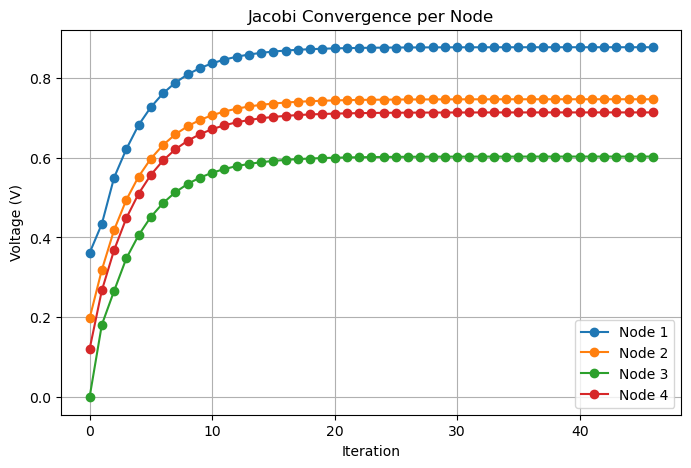

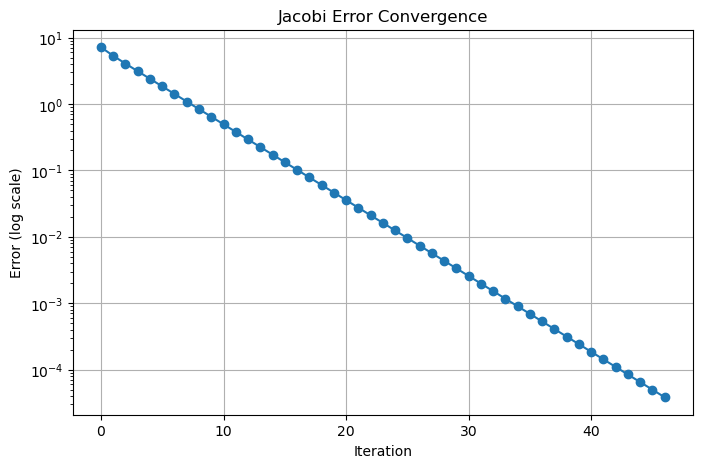

In [6]:
x_jacobi, jacobi_iter = jacobi_method(A_reduced, b)

jacobi_error = np.linalg.norm(x_exact - x_jacobi, ord=np.inf)

print("Jacobi solution:")
for idx, val in enumerate(x_jacobi, start=1):
    print(f"Node {idx}: {val:.6f} V")

print(f"Jacobi iterations: {jacobi_iter}")
print(f"Jacobi error: {jacobi_error:.10e}")


def jacobi_trace(A, b, tol=1e-6, max_iter=100):
    n = len(b)
    x = np.zeros(n)
    x_new = np.zeros(n)
    history = []
    errors = []

    for _ in range(max_iter):
        for i in range(n):
            s = sum(A[i, j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i, i]

        history.append(x_new.copy())

        error = np.linalg.norm(A @ x_new - b)
        errors.append(error)

        if np.linalg.norm(x_new - x, ord=np.inf) < tol:
            break

        x = x_new.copy()

    return np.array(history), np.array(errors)


jacobi_hist, jacobi_errors = jacobi_trace(A_reduced, b)


plt.figure(figsize=(8,5))
for i in range(jacobi_hist.shape[1]):
    plt.plot(jacobi_hist[:, i], marker='o', label=f"Node {i+1}")
plt.xlabel("Iteration")
plt.ylabel("Voltage (V)")
plt.title("Jacobi Convergence per Node")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8,5))
plt.plot(jacobi_errors, marker='o')
plt.yscale('log')
plt.xlabel("Iteration")
plt.ylabel("Error (log scale)")
plt.title("Jacobi Error Convergence")
plt.grid(True)
plt.show()

In [7]:
def gauss_seidel_method(A, b, tol=1e-6, max_iter=100):
    n = len(b)
    x = np.zeros(n)
    iterations = 0

    for k in range(max_iter):
        x_old = x.copy()

        for i in range(n):
            s1 = sum(A[i, j] * x[j] for j in range(i))
            s2 = sum(A[i, j] * x_old[j] for j in range(i + 1, n))
            x[i] = (b[i] - s1 - s2) / A[i, i]

        iterations += 1

        if np.linalg.norm(x - x_old, ord=np.inf) < tol:
            return x, iterations

    return x, iterations

Gauss-Seidel solution:
Node 1: 0.876096 V
Node 2: 0.745872 V
Node 3: 0.602448 V
Node 4: 0.712934 V
Gauss-Seidel iterations: 26
Gauss-Seidel error: 1.3523752089e-06


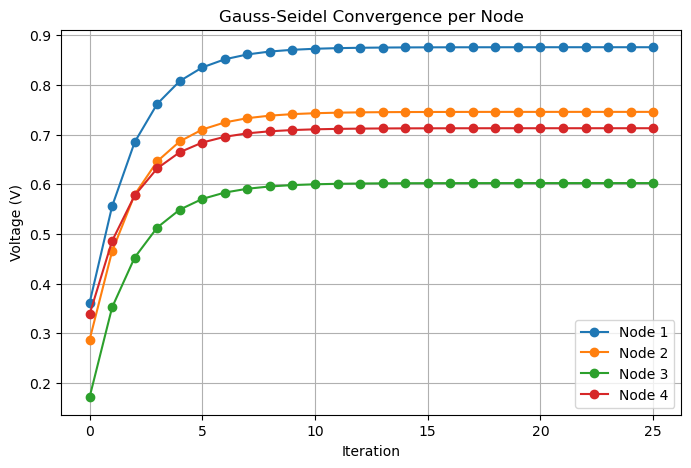

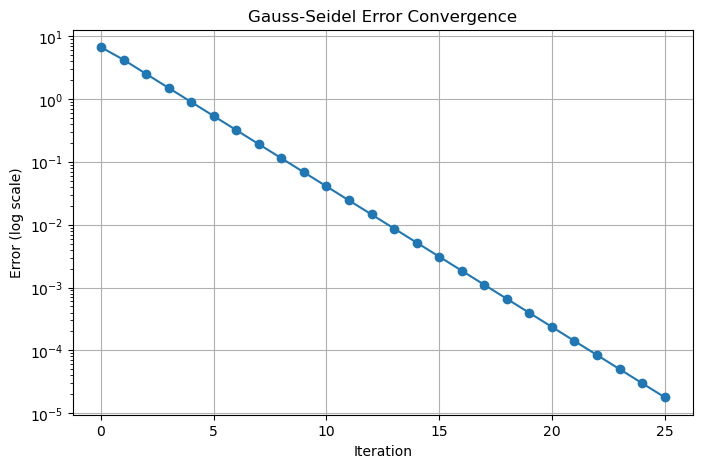

In [8]:
x_gs, gs_iter = gauss_seidel_method(A_reduced, b)

gs_error = np.linalg.norm(x_exact - x_gs, ord=np.inf)

print("Gauss-Seidel solution:")
for idx, val in enumerate(x_gs, start=1):
    print(f"Node {idx}: {val:.6f} V")

print(f"Gauss-Seidel iterations: {gs_iter}")
print(f"Gauss-Seidel error: {gs_error:.10e}")

def gs_trace(A, b, tol=1e-6, max_iter=100):
    n = len(b)
    x = np.zeros(n)
    history = []
    errors = []

    for _ in range(max_iter):
        x_old = x.copy()

        for i in range(n):
            s1 = sum(A[i, j] * x[j] for j in range(i))
            s2 = sum(A[i, j] * x_old[j] for j in range(i+1, n))
            x[i] = (b[i] - s1 - s2) / A[i, i]

        history.append(x.copy())

        error = np.linalg.norm(A @ x - b)
        errors.append(error)

        if np.linalg.norm(x - x_old, ord=np.inf) < tol:
            break

    return np.array(history), np.array(errors)


gs_hist, gs_errors = gs_trace(A_reduced, b)

plt.figure(figsize=(8,5))
for i in range(gs_hist.shape[1]):
    plt.plot(gs_hist[:, i], marker='o', label=f"Node {i+1}")
plt.xlabel("Iteration")
plt.ylabel("Voltage (V)")
plt.title("Gauss-Seidel Convergence per Node")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8,5))
plt.plot(gs_errors, marker='o')
plt.yscale('log')
plt.xlabel("Iteration")
plt.ylabel("Error (log scale)")
plt.title("Gauss-Seidel Error Convergence")
plt.grid(True)
plt.show()

In [9]:
def sor_method(A, b, omega=1.1, tol=1e-6, max_iter=100):
    n = len(b)
    x = np.zeros(n)
    iterations = 0

    for k in range(max_iter):
        x_old = x.copy()

        for i in range(n):
            s1 = sum(A[i, j] * x[j] for j in range(i))
            s2 = sum(A[i, j] * x_old[j] for j in range(i + 1, n))
            x[i] = (1 - omega) * x_old[i] + (omega / A[i, i]) * (b[i] - s1 - s2)

        iterations += 1

        if np.linalg.norm(x - x_old, ord=np.inf) < tol:
            return x, iterations

    return x, iterations

def sor_trace(A, b, omega=1.1, tol=1e-6, max_iter=100):
    n = len(b)
    x = np.zeros(n)
    history = []

    for k in range(max_iter):
        x_old = x.copy()

        for i in range(n):
            s1 = sum(A[i, j] * x[j] for j in range(i))
            s2 = sum(A[i, j] * x_old[j] for j in range(i + 1, n))
            x[i] = (1 - omega) * x_old[i] + (omega / A[i, i]) * (b[i] - s1 - s2)

        history.append(x.copy())

        if np.linalg.norm(x - x_old, ord=np.inf) < tol:
            break

    return history

SOR solution:
Node 1: 0.876098 V
Node 2: 0.745873 V
Node 3: 0.602449 V
Node 4: 0.712935 V
SOR iterations: 13
SOR error: 1.1079622664e-07
Omega used: 1.25


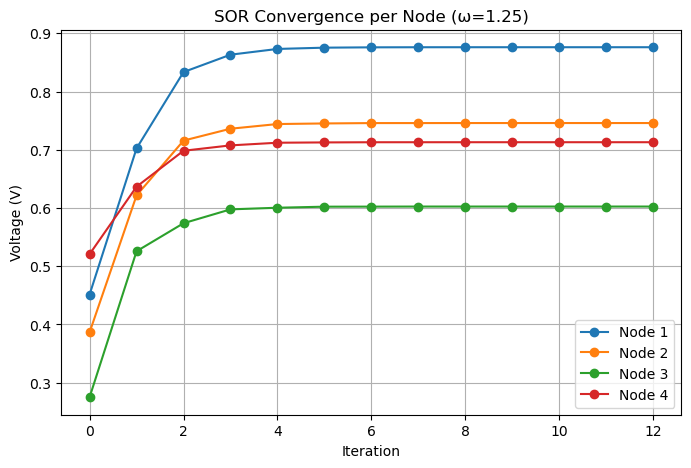

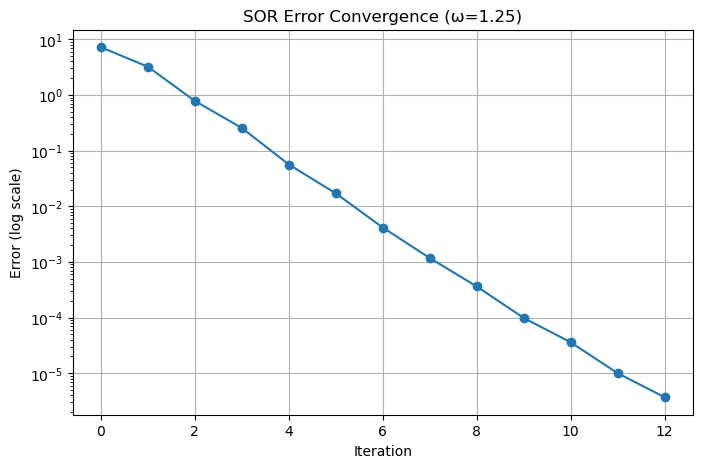


SOR Performance Table for different ω:
   Omega  Iterations         Error
0   1.05          24  7.146356e-07
1   1.10          21  6.815355e-07
2   1.25          13  1.107962e-07
3   1.50          23  2.603626e-07


In [10]:
best_omega = 1.25

x_sor, sor_iter = sor_method(A_reduced, b, omega=best_omega)

sor_error = np.linalg.norm(x_exact - x_sor, ord=np.inf)

print("SOR solution:")
for idx, val in enumerate(x_sor, start=1):
    print(f"Node {idx}: {val:.6f} V")

print(f"SOR iterations: {sor_iter}")
print(f"SOR error: {sor_error:.10e}")
print(f"Omega used: {best_omega}")

def sor_trace_with_error(A, b, omega=1.25, tol=1e-6, max_iter=100):
    n = len(b)
    x = np.zeros(n)
    history = []
    errors = []
    
    for _ in range(max_iter):
        x_old = x.copy()
        for i in range(n):
            s1 = sum(A[i, j] * x[j] for j in range(i))
            s2 = sum(A[i, j] * x_old[j] for j in range(i+1, n))
            x[i] = (1 - omega) * x_old[i] + (omega / A[i,i]) * (b[i] - s1 - s2)
        history.append(x.copy())
        # Error based on Ax-b
        errors.append(np.linalg.norm(A @ x - b))
        if np.linalg.norm(x - x_old, ord=np.inf) < tol:
            break
    return np.array(history), np.array(errors)

sor_hist, sor_errors = sor_trace_with_error(A_reduced, b, omega=best_omega)

plt.figure(figsize=(8,5))
for i in range(sor_hist.shape[1]):
    plt.plot(sor_hist[:,i], marker='o', label=f"Node {i+1}")
plt.xlabel("Iteration")
plt.ylabel("Voltage (V)")
plt.title(f"SOR Convergence per Node (ω={best_omega})")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8,5))
plt.plot(sor_errors, marker='o')
plt.yscale('log')
plt.xlabel("Iteration")
plt.ylabel("Error (log scale)")
plt.title(f"SOR Error Convergence (ω={best_omega})")
plt.grid(True)
plt.show()

omegas = [1.05, 1.10, 1.25, 1.50]
sor_results = []

for omega_val in omegas:
    x_tmp, iter_tmp = sor_method(A_reduced, b, omega=omega_val)
    error_tmp = np.linalg.norm(x_exact - x_tmp, ord=np.inf)
    sor_results.append({
        "Omega": omega_val,
        "Iterations": iter_tmp,
        "Error": error_tmp
    })

sor_perf_table = pd.DataFrame(sor_results)
print("\nSOR Performance Table for different ω:")
print(sor_perf_table)

          Method Iterations         Error
0  Direct Solver        N/A  0.000000e+00
1         Jacobi         47  3.243550e-06
2   Gauss-Seidel         26  1.352375e-06
3            SOR         13  1.107962e-07


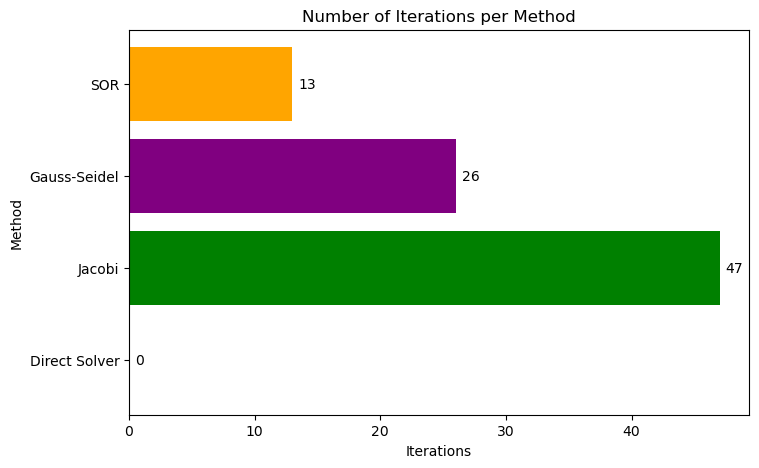

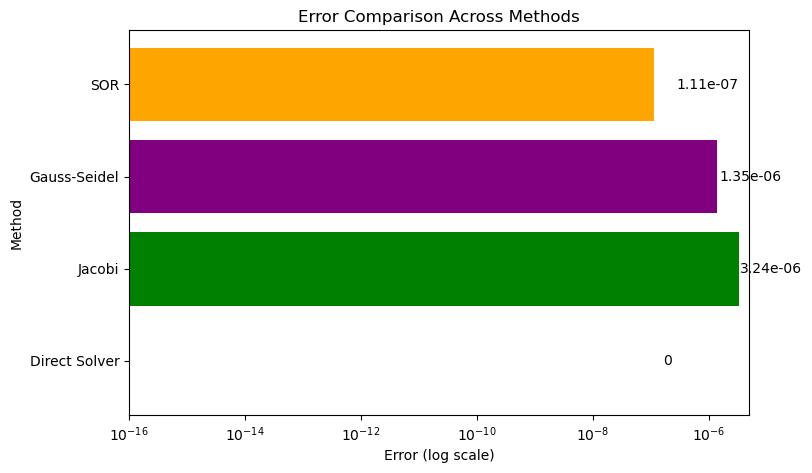

In [11]:
results = pd.DataFrame({
    "Method": ["Direct Solver", "Jacobi", "Gauss-Seidel", "SOR"],
    "Iterations": ["N/A", jacobi_iter, gs_iter, sor_iter],
    "Error": [0.0, jacobi_error, gs_error, sor_error]
})

print(results)

colors = ["skyblue", "green", "purple", "orange"]


iterations = [0 if x == "N/A" else x for x in results["Iterations"]]

plt.figure(figsize=(8,5))
plt.barh(results["Method"], iterations, color=colors)

for i, v in enumerate(iterations):
    plt.text(v + 0.5, i, f"{v}", va='center')

plt.xlabel("Iterations")
plt.ylabel("Method")
plt.title("Number of Iterations per Method")
plt.show()



plt.figure(figsize=(8,5))

errors = results["Error"].copy()
y_pos = np.arange(len(errors))


plot_errors = [e if i != 0 else 1e-16 for i, e in enumerate(errors)]

plt.barh(y_pos, plot_errors, color=colors)
plt.yticks(y_pos, results["Method"])

# Add labels
offset = max(errors[1:]) * 0.05  
for i, v in enumerate(plot_errors):
    if i == 0:
        plt.text(v + offset, i, "0", va='center')  
    else:
        plt.text(v + offset, i, f"{errors[i]:.2e}", va='center')

plt.xlabel("Error (log scale)")
plt.ylabel("Method")
plt.title("Error Comparison Across Methods")
plt.xscale('log')

plt.xlim(1e-16, max(errors[1:]) * 1.5)  

plt.show()